# *#Clusterring Using Income Spent*

## Importing the basic libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Load Dataset from Local Directory

In [2]:
from google.colab import files
uploaded = files.upload()

Saving dataset.csv to dataset.csv


## Importing the dataset

In [3]:
dataset = pd.read_csv('dataset.csv')

### Summarize Dataset

In [4]:
print(dataset.shape)
print(dataset.info())
print(dataset.describe())
print(dataset.head())

(303, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   INCOME  303 non-null    int64
 1   SPEND   303 non-null    int64
dtypes: int64(2)
memory usage: 4.9 KB
None
           INCOME       SPEND
count  303.000000  303.000000
mean   245.273927  149.646865
std     48.499412   22.905161
min    126.000000   71.000000
25%    211.000000  133.500000
50%    240.000000  153.000000
75%    274.000000  166.000000
max    417.000000  202.000000
   INCOME  SPEND
0     233    150
1     250    187
2     204    172
3     236    178
4     354    163


### Segregate & Zipping Dataset

In [5]:
X = dataset[['INCOME','SPEND']].values

### Finding the Optimized K Value

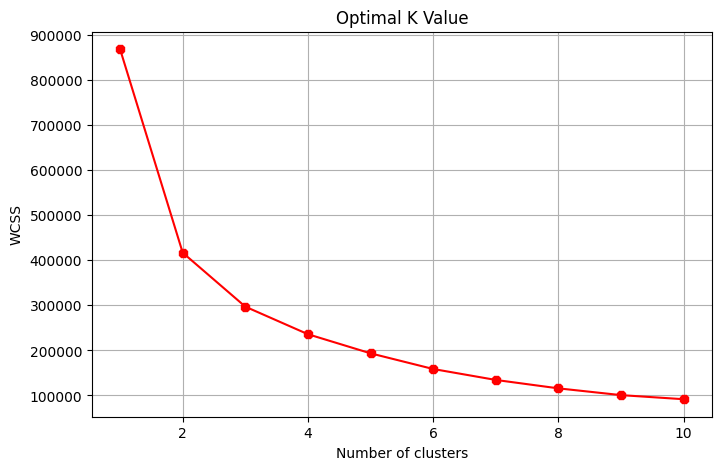

In [6]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1,11):
  km = KMeans(n_clusters=i, init="k-means++", n_init=10, random_state=0)
  km.fit(X)
  wcss.append(km.inertia_)
plt.figure(figsize=(8,5))
plt.plot(range(1,11),wcss,color="red", marker ="8")
plt.title('Optimal K Value')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

### Fitting the k-means to the dataset with k=4

In [7]:
model=KMeans(n_clusters=4, random_state=0)
y_means = model.fit_predict(X)

### Visualizing the clusters for k=4

Cluster 1: Customers with medium income and low spend

Cluster 2: Customers with high income and medium to high spend

Cluster 3: Customers with low income

Cluster 4: Customers with medium income but high spend

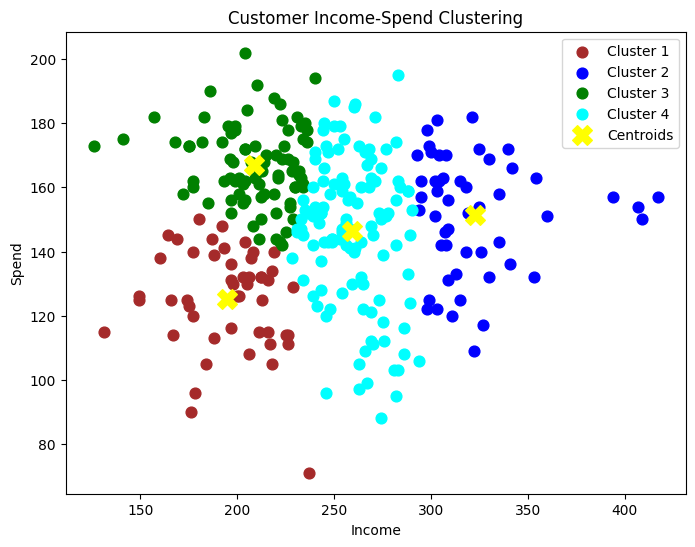

In [8]:
plt.figure(figsize=(8,6))

colors = ['brown','blue','green','cyan']

for i in range(4):
    plt.scatter(X[y_means==i,0],
                X[y_means==i,1],
                s=60,
                c=colors[i],
                label=f'Cluster {i+1}')

plt.scatter(model.cluster_centers_[:,0],
            model.cluster_centers_[:,1],
            s=200,
            c='yellow',
            marker='X',
            label='Centroids')

plt.title("Customer Income-Spend Clustering")
plt.xlabel("Income")
plt.ylabel("Spend")
plt.legend()
plt.show()

# *User Input Prediction Code*

In [11]:
# ---------- User Input ----------

income = float(input("Enter Customer Income: "))
splend = float(input("Enter Customer Spending: "))

new_customer = np.array([[income, splend]])

# Predict cluster
cluster = model.predict(new_customer)

print("\nCustomer belongs to Cluster:", cluster[0]+1)

if cluster[0] == 0:
    print("Customer Type: Medium Income - Low Spend")
elif cluster[0] == 1:
    print("Customer Type: High Income - High Spend")
elif cluster[0] == 2:
    print("Customer Type: Low Income Customer")
elif cluster[0] == 3:
    print("Customer Type: Medium Income - High Spend")

Enter Customer Income: 34246
Enter Customer Spending: 23666

Customer belongs to Cluster: 2
Customer Type: High Income - High Spend
